In [1]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
import collections
from collections import deque, defaultdict, OrderedDict
import os
import math
import random
import re
from pathlib import Path
from scipy import optimize
from matplotlib.path import Path
import matplotlib.patches as patches
from scipy.interpolate import splprep, splev

In [ ]:
#names of the dot files that contain the data:
data_name_1 = "../Datasets/JazzNetwork.dot"
data_name_2 = "../Datasets/LesMiserables.dot"
data_name_3 = "../Datasets/devonshiredebate_withclusters.dot"
data_name_4 = "../Datasets/g.20.27.dot"
data_name_5 = "../Datasets/g.42.88.dot"
data_name_6 = "../Datasets/GD97.dot"
data_name_7 = "../Datasets/LeagueNetwork.dot" 
data_name_8 = "../Datasets/mesh graph.dot"
data_name_9 = "../Datasets/noname.dot" 
data_name_10 = "../Datasets/polblogs.dot"
data_name_11 = "../Datasets/robot graph.dot"
data_name_12 = "../Datasets/rome.dot"
data_name_13 = "../Datasets/snail graph.dot"

# Functions

In [3]:
def parse_dot_file(file_path):
    """
    Process the input data (path of the graph) and extract nodes and edges. 
    If the graph is undirected, it will be converted to a directed graph by putting both way edges (i.e. A->B and B->A).
    """

    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)

    # Extract nodes and edges without their attributes
    nodes = nx_graph.nodes(data=False)
    edges = list(nx_graph.edges(data=False))  # Convert EdgeView to list

    # Check graph type
    is_directed = nx.is_directed(nx_graph)
    print(f"Graph is {'directed' if is_directed else 'undirected'}")
    
    if not is_directed:
        print(f"\nNumber of edges before conversion: {len(edges)}")
        # Create a new list with reversed edges and extend the original list
        reversed_edges = [(v, u) for u, v in edges]
        edges.extend(reversed_edges)
        print(f"\nNumber of edges after conversion: {len(edges)}")

    return list(nodes), edges

def circular_visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib."""
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("circular visualization of the graph")
    plt.show()

def trivial_heuristic(nodes, edges):
    """
    Identify edges that need to be reversed from the ordering of the nodes, in order to remove cycles.
    
    Args:
        nodes: List of nodes in the graph
        edges: List of edges as tuples (source, destination)
        
    Returns:
        tuple: (A, A_reverse) where:
            - A: List of edges that should remain unchanged (left to right)
            - A_reverse: List of edges that should be reversed (right to left)
    """
    # Create node positions ordering
    node_pos_ordered = {node: np.array([idx]) for idx, node in enumerate(nodes)}
     
    # Separate edges into those to keep and those to reverse
    A = []  # edges to keep (left to right)
    A_reverse = []  # edges to reverse (right to left)
    
    for src, dest in edges:
        # If destination is to the left of source, it's a backward edge
        if node_pos_ordered[dest] < node_pos_ordered[src]:
            A_reverse.append((src, dest))
        else:
            A.append((src, dest))
    
    return A, A_reverse

def reversed_edges(A, A_reverse):
    """Return the reversed edges that solve the loops"""
    A_reversed = [(dst, src) for src, dst in A_reverse]
    print(f"\nNumber of edges that have been reversed: {len(A_reversed)}")
    print(f"\nList of reversed edges: {A_reversed}")
    final_reversed = A_reversed + A
    
    return final_reversed, A_reversed

def circular_reverse_graph(nodes, edges, reversed_e, unchanged_e):
    """
    Plot the directed graph using Matplotlib.
    
    Parameters:
        nodes: List of nodes
        edges: List of all edges
        reversed_e: List of edges that were changed (to be drawn in red)
        unchanged_e: List of edges that were not changed (to be drawn in black)
    """

    # Assign positions to nodes (circular layout)
    V = len(nodes)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)
    
    # Plot unchanged edges
    for src, dst in unchanged_e:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        edge_color = "black"  # Unchanged edges in black with thinner lines
        lw_mod = 0.5
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color=edge_color, lw = lw_mod, alpha=0.7))

    # Plot reversed edges
    for src, dst in reversed_e:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        edge_color = "red"    # Changed edges in red with thicker lines
        lw_mod = 3
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color=edge_color, lw = lw_mod, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)


    plt.title("circular graph visualization with reversed edges drawn in red")
    plt.show()

def find_sources(nodes, edges):
    #Find nodes with no incoming edges.
    
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    incoming_edges = {node: 0 for node in all_nodes}
    for src, dst in edges:
        incoming_edges[dst] += 1.
    return [node for node, count in incoming_edges.items() if count == 0]

def add_dummy_nodes(layers, edges):

    # Create node to layer mapping
    node_to_layer = {}
    for i, layer in enumerate(layers):
        for node in layer:
            node_to_layer[node] = i
    
    modified_layers = [layer[:] for layer in layers]
    modified_edges = []
    dummy_mapping = {}  
    dummy_counter = 0
    
    for source, target in edges:
        source_layer = node_to_layer[source]
        target_layer = node_to_layer[target]
        
        if target_layer - source_layer > 1:
            # Edge spaning multiple layers, needs dummy nodes
            current = source
            for layer_idx in range(source_layer + 1, target_layer):
                dummy_name = f"dummy_{dummy_counter}"
                dummy_counter += 1
                
                # Add dummy node to layer
                modified_layers[layer_idx].append(dummy_name)
                
                # Add edge to dummy node
                modified_edges.append((current, dummy_name))
                dummy_mapping[dummy_name] = (source, target)
                current = dummy_name
            
            # Connect last dummy node to target
            modified_edges.append((current, target))
        else:
            modified_edges.append((source, target))
    
    return modified_layers, modified_edges, dummy_mapping

def find_sinks(nodes, edges):
    #Find nodes with no outgoing edge
    
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    # Find nodes that appear as sources but not as destinations
    outgoing_edges = {node: 0 for node in all_nodes}
    for src, dst in edges:
        outgoing_edges[src] += 1
    return [node for node, count in outgoing_edges.items() if count == 0]

def sugiyama_layer_assignment(nodes, edges):

    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    

    sink_nodes = set(find_sinks(nodes, edges))
    
    # Remove sink nodes from consideration for initial layering
    working_nodes = all_nodes - sink_nodes
    working_edges = [(src, dst) for src, dst in edges if dst not in sink_nodes]
    
    layers = [] 
    remaining_nodes = working_nodes.copy()
    remaining_edges = working_edges.copy()

    # Layer assignment for non-sink nodes
    while remaining_nodes:
        sources = find_sources(remaining_nodes, remaining_edges)
        
        if not sources:
            raise ValueError("Graph contains cycles or is disconnected.")
        
        layers.append(sources)
        remaining_nodes -= set(sources)
        remaining_edges = [(src, dst) for src, dst in remaining_edges if src not in sources]
    
    # Add sink nodes as the final layer
    if sink_nodes:
        layers.append(list(sink_nodes))
    
    # Add dummy nodes for long edges
    layers_with_dummies, modified_edges, dummy_mapping = add_dummy_nodes(layers, edges)
    
    return layers_with_dummies, modified_edges, dummy_mapping
def draw_layered_graph(layers, edges, dummy_mapping=None):
    
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
    
        num_nodes = len(layer_nodes)
        x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
        
        
        for node_idx, node in enumerate(layer_nodes):
            x = x_positions[node_idx]
            y = y_position
            node_positions[node] = (x, y)
            
            is_dummy = str(node).startswith('dummy_')
            
            if is_dummy:
                # Dummy nodes as diamonds
                plt.scatter(x, y, s=200, color='lightyellow', 
                          edgecolor='gray', marker='D', zorder=3)
                plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                        va='center', fontsize=8, color='gray')
            else:
                # Regular nodes as circles
                plt.scatter(x, y, s=500, color='lightblue', 
                          edgecolor='black', zorder=3)
                plt.text(x, y, node, ha='center', va='center', 
                        fontweight='bold', zorder=4)
    
    # Draw edges with arrows
    for source, target in edges:
        if source in node_positions and target in node_positions:
            x_source, y_source = node_positions[source]
            x_target, y_target = node_positions[target]
            
            is_dummy_edge = (str(source).startswith('dummy_') or 
                           str(target).startswith('dummy_'))
            
             
            plt.annotate('', 
                xy=(x_target, y_target),  # arrow tip
                xytext=(x_source, y_source),  # arrow base
                arrowprops=dict(
                    arrowstyle='->',  
                    color='gray' if is_dummy_edge else 'black',
                    alpha=0.3 if is_dummy_edge else 0.6,
                    connectionstyle='arc3,rad=0',  # straight lines
                    linewidth=2, 
                    mutation_scale=20,  # increased arrow size
                    shrinkA=10,  # shrink start of arrow
                    shrinkB=10   # shrink end of arrow
                ),
                zorder=2
            )
    
    # layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
               marker='D', label='Dummy Nodes')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.title('Layered Graph Layout with Dummy Nodes')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    return node_positions



# Edge crossing count 
def count_edge_crossings(positions, edges):

    def line_segments_intersect(p1, p2, p3, p4):
        """
        Check if line segments (p1, p2) and (p3, p4) intersect.
        Each point is a tuple (x, y).
        """
        def orientation(p, q, r):
            # Calculate orientation of triplet (p, q, r)
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            if val == 0: return 0   # Collinear
            return 1 if val > 0 else 2  # Clockwise or Counterclockwise
        
        def on_segment(p, q, r):
            # Check if point q lies on line segment pr
            return (q[0] <= max(p[0], r[0]) and q[0] >= min(p[0], r[0]) and
                    q[1] <= max(p[1], r[1]) and q[1] >= min(p[1], r[1]))
        
        # Find orientations
        o1 = orientation(p1, p2, p3)
        o2 = orientation(p1, p2, p4)
        o3 = orientation(p3, p4, p1)
        o4 = orientation(p3, p4, p2)
        
        # General case: different orientations
        if o1 != o2 and o3 != o4:
            return True
        
        # Special cases: collinearity
        if o1 == 0 and on_segment(p1, p3, p2): return True
        if o2 == 0 and on_segment(p1, p4, p2): return True
        if o3 == 0 and on_segment(p3, p1, p4): return True
        if o4 == 0 and on_segment(p3, p2, p4): return True
        
        return False   
    
    crossings = 0
    crossing_edges = []
    
    # Check each pair of edges
    for i in range(len(edges)):
        src1, dst1 = edges[i]
        # Skip if we don't have position data for these nodes
        if src1 not in positions or dst1 not in positions:
            continue
            
        p1 = positions[src1]
        p2 = positions[dst1]
        
        for j in range(i+1, len(edges)):
            src2, dst2 = edges[j]
            # Skip if no position data for these nodes
            if src2 not in positions or dst2 not in positions:
                continue
                
            p3 = positions[src2]
            p4 = positions[dst2]
            
            # Check if the edges share an endpoint
            if src1 == src2 or src1 == dst2 or dst1 == src2 or dst1 == dst2:
                continue  # cant count as crossings if they share endpoint
            
            # Check if line segments intersect
            if line_segments_intersect(p1, p2, p3, p4):
                crossings += 1
                crossing_edges.append(((src1, dst1), (src2, dst2)))
    
    return crossings, crossing_edges


def get_node_order(layer):
    #To get current order of nodes in a layer
    return {node: idx for idx, node in enumerate(layer)}

def get_median_position(node, connected_nodes, node_order):
 
    if not connected_nodes:
        return float('inf')
    positions = sorted([node_order[n] for n in connected_nodes])
    n = len(positions)
    if n % 2 == 1:
        return positions[n // 2]
    return (positions[(n-1) // 2] + positions[n // 2]) / 2

def get_barycenter_position(node, connected_nodes, node_order):
    
    if not connected_nodes:
        return float('inf')
    return sum(node_order[n] for n in connected_nodes) / len(connected_nodes)

def count_crossings(layer1, layer2, edges):
    #Count number of edge crossings between two adjacent layers
    crossings = 0
    layer1_order = {node: idx for idx, node in enumerate(layer1)}
    layer2_order = {node: idx for idx, node in enumerate(layer2)}
    
    edges_between = [(s, t) for s, t in edges if s in layer1_order and t in layer2_order]
    for i, (s1, t1) in enumerate(edges_between):
        for s2, t2 in edges_between[i+1:]:
            if (layer1_order[s1] - layer1_order[s2]) * (layer2_order[t1] - layer2_order[t2]) < 0:
                crossings += 1
    return crossings

def count_all_crossings(layers, edges):
   
    total = 0
    for i in range(len(layers) - 1):
        total += count_crossings(layers[i], layers[i+1], edges)
    return total

def minimize_crossings(layers, edges, max_iterations=10, method='barycenter', collect_stats=False):
    
    previous_down_crossings = float('inf')
    previous_up_crossings = float('inf')
    
    # Create adjacency lists for quick lookup
    successors = {node: [] for layer in layers for node in layer}
    predecessors = {node: [] for layer in layers for node in layer}
    
    for source, target in edges:
        successors[source].append(target)
        predecessors[target].append(source)
    
    position_func = get_barycenter_position if method == 'barycenter' else get_median_position
    
    initial_crossings = count_all_crossings(layers, edges)
    print(f"\nInitial crossing count: {initial_crossings}")
    print("-" * 40)
    
    # List to store crossing statistics if requested
    crossing_stats = []
    
    for iteration in range(max_iterations):
        improved = False
        print(f"\nIteration {iteration + 1}")
        
        if collect_stats:
            iteration_stats = {
                "iteration": iteration + 1,
                "initial": initial_crossings if iteration == 0 else previous_up_crossings
            }
        
        # Sweep down
        for i in range(1, len(layers)):
            fixed_order = get_node_order(layers[i-1])
            current_layer = layers[i]
            
            positions = [(position_func(node, predecessors[node], fixed_order), node) 
                        for node in current_layer]
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        down_crossings = count_all_crossings(layers, edges)
        print(f"After downward sweep: {down_crossings} crossings")
        
        if collect_stats:
            iteration_stats["down_sweep"] = down_crossings
        
        # Sweep up
        for i in range(len(layers)-2, -1, -1):
            fixed_order = get_node_order(layers[i+1])
            current_layer = layers[i]
            
            positions = [(position_func(node, successors[node], fixed_order), node) 
                        for node in current_layer]
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        up_crossings = count_all_crossings(layers, edges)
        print(f"After upward sweep: {up_crossings} crossings")
        
        if collect_stats:
            iteration_stats["up_sweep"] = up_crossings
            iteration_stats["crossings_reduced"] = iteration_stats["initial"] - up_crossings
            crossing_stats.append(iteration_stats)
        
        # Check for termination conditions
        if down_crossings == previous_down_crossings and up_crossings == previous_up_crossings:
            print("\nPattern repeats (same crossing counts as previous iteration), stopping...")
            break
        
        previous_down_crossings = down_crossings
        previous_up_crossings = up_crossings
        
        if not improved:
            print("\nNo node order changes, stopping...")
            break
    
    final_crossings = count_all_crossings(layers, edges)
    print(f"\nFinal crossing count: {final_crossings}")
    print(f"Total reduction: {initial_crossings - final_crossings} crossings")
    
    if collect_stats:
        # Add final summary to stats
        crossing_stats.append({
            "iteration": "final",
            "initial": initial_crossings,
            "final": final_crossings,
            "total_reduction": initial_crossings - final_crossings
        })
        return crossing_stats
    
    return layers


def build_paths_from_layer_0(positions, modified_edges, dummy_mapping, max_depth=None):
    """
    For each node in layer 0, find ALL possible paths (u, d1, ..., dk, v) where:
    - u is a node in layer 0
    - d1, ..., dk are nodes (dummy or regular) along the path
    - v is any reachable node with no outgoing edges
    
    Parameters:
        positions: Dictionary mapping node IDs to (x, y) coordinates
        modified_edges: List of edges including dummy nodes
        dummy_mapping: Dictionary mapping dummy nodes to (source, target) tuples
        max_depth: Maximum path length (None for unlimited)
    
    Returns:
        List of paths, where each path is a dictionary with path information
    """
    
    # Identify nodes in layer 0
    layer_0_nodes = [node for node, (_, y) in positions.items() if int(y) == 0]
    print(f"Found {len(layer_0_nodes)} nodes in layer 0")
    
    # Build adjacency list from modified edges
    graph = collections.defaultdict(list)
    for src, dst in modified_edges:
        graph[src].append(dst)
    
    # Identify dummy nodes
    dummy_nodes = set(dummy_mapping.keys())
    
    # Get the layer for each node (will be used to ensure we only go forward)
    node_layers = {node: int(y) for node, (_, y) in positions.items()}
    
    # Track all found paths
    all_paths = []
    
    # DFS to find all paths from a source node
    def find_all_paths(source, current_path=None, visited=None):
        if current_path is None:
            current_path = [source]
        if visited is None:
            visited = set([source])
        
        # Check if we've reached maximum depth
        if max_depth is not None and len(current_path) >= max_depth:
            # Add the path if it has at least one edge
            if len(current_path) > 1:
                all_paths.append({
                    "source": current_path[0],
                    "target": current_path[-1],
                    "path": current_path.copy(),
                    "dummy_nodes": [n for n in current_path if n in dummy_nodes],
                    "length": len(current_path)
                })
            return
        
        # Check if this is a sink node (no outgoing edges)
        if not graph[current_path[-1]]:
            # We've reached the end of a path
            if len(current_path) > 1:  # Only add paths with at least one edge
                all_paths.append({
                    "source": current_path[0],
                    "target": current_path[-1],
                    "path": current_path.copy(),
                    "dummy_nodes": [n for n in current_path if n in dummy_nodes],
                    "length": len(current_path)
                })
            return
        
        # Current node and its layer
        current_node = current_path[-1]
        current_layer = node_layers[current_node]
        
        # Explore all neighbors
        for neighbor in graph[current_node]:
            # Skip if already visited (avoid cycles)
            if neighbor in visited:
                continue
            
            # Only go forward in layers to maintain DAG property
            if node_layers.get(neighbor, float('inf')) <= current_layer:
                continue
            
            # Add neighbor to path
            current_path.append(neighbor)
            visited.add(neighbor)
            
            # Recursively find all paths from neighbor
            find_all_paths(source, current_path, visited)
            
            # Backtrack
            current_path.pop()
            visited.remove(neighbor)
    
    # Process each layer 0 node
    for i, node in enumerate(layer_0_nodes):
        print(f"Finding paths from node {node} ({i+1}/{len(layer_0_nodes)})")
        find_all_paths(node)
    
    # Sort paths by length (longest first)
    all_paths.sort(key=lambda x: x["length"], reverse=True)
    
    print(f"Found {len(all_paths)} total paths from layer 0 nodes")
    return all_paths

def straighten_paths_quadratic_program(paths, positions, dummy_mapping, min_distance=0.05, max_iterations=500):
    """
    Use quadratic programming to minimize the total deviation of paths from straight lines,
    with integrated deviation calculations during the optimization process.
    
    Parameters:
        paths: List of paths from build_paths_from_layer_0 function
        positions: Dictionary mapping node IDs to (x, y) coordinates
        dummy_mapping: Dictionary mapping dummy nodes to (source, target) tuples
        min_distance: Minimum horizontal distance between consecutive nodes on same layer
        max_iterations: Maximum number of iterations for the optimizer
    
    Returns:
        Dictionary with new optimized positions
    """
    
    print("Optimizing node positions to straighten paths...")
    
    # Group nodes by layer
    layers = defaultdict(list)
    for node, (x, y) in positions.items():
        layer = int(y)
        layers[layer].append(node)
    
    # Sort nodes within each layer by x-coordinate
    for layer in layers:
        layers[layer].sort(key=lambda node: positions[node][0])
    
    # Create a mapping from node names to indices in the optimization vector
    nodes_list = sorted(positions.keys(), key=lambda node: (positions[node][1], positions[node][0]))
    node_indices = {node: i for i, node in enumerate(nodes_list)}
    
    print(f"Preparing optimization for {len(nodes_list)} nodes across {len(layers)} layers")
    
    # Define a function to calculate current positions from x-values vector
    def get_positions_from_x_values(x_values):
        current_positions = {}
        for node, idx in node_indices.items():
            _, y = positions[node]  # Keep original y-coordinate
            current_positions[node] = (x_values[idx], y)
        return current_positions
    
    # Define a function to calculate path deviations based on positions
    def calculate_deviations(current_positions):
        path_deviations = OrderedDict()
        
        for path_idx, path_info in enumerate(paths):
            path = path_info['path']
            if len(path) <= 2:
                continue
                
            source_node = path[0]
            target_node = path[-1]
            source_x = current_positions[source_node][0]
            target_x = current_positions[target_node][0]
            
            total_deviation = 0
            node_deviations = []
            
            for i, node in enumerate(path[1:], 1):
                t = i / (len(path) - 1)
                ideal_x = source_x + t * (target_x - source_x)
                
                current_x = current_positions[node][0]
                deviation = (current_x - ideal_x) ** 2
                total_deviation += deviation
                
                node_deviations.append({
                    'node': node,
                    'deviation': deviation
                })
            
            path_deviations[path_idx] = {
                'total_deviation': total_deviation,
                'node_deviations': node_deviations
            }
        
        # Calculate total deviation across all paths
        total_deviation = sum(p['total_deviation'] for p in path_deviations.values())
        return total_deviation, path_deviations
    
    # Objective function for the optimizer
    def objective(x_values):
        # Get current positions from x_values
        current_positions = get_positions_from_x_values(x_values)
        
        # Calculate total deviation
        total_deviation, _ = calculate_deviations(current_positions)
        
        # Add small regularization term to maintain stability
        reg_weight = 0.1
        reg_term = 0
        for i, node in enumerate(nodes_list):
            orig_x = positions[node][0]
            new_x = x_values[i]
            reg_term += reg_weight * (new_x - orig_x) ** 2
            
        return total_deviation + reg_term
    
    # Create constraints for minimum distance between consecutive nodes in same layer
    constraints = []
    for layer, layer_nodes in layers.items():
        for i in range(len(layer_nodes) - 1):
            left_node = layer_nodes[i]
            right_node = layer_nodes[i + 1]
            
            # Constraint: right_node.x - left_node.x >= min_distance
            constraints.append({
                'type': 'ineq',
                'fun': lambda x, i1=node_indices[left_node], i2=node_indices[right_node]: 
                       x[i2] - x[i1] - min_distance
            })
    
    print(f"Created {len(constraints)} ordering constraints")
    
    # Initial values = current x-coordinates
    x0 = [positions[node][0] for node in nodes_list]
    
    # Calculate initial deviation for comparison
    initial_positions = positions.copy()
    initial_total_deviation, initial_path_deviations = calculate_deviations(initial_positions)
    print(f"Initial total deviation: {initial_total_deviation:.4f}")
    
    # Set bounds to prevent extreme movement
    min_x = min(pos[0] for pos in positions.values())
    max_x = max(pos[0] for pos in positions.values())
    margin = 0.2 * (max_x - min_x)  # Allow 20% margin on each side
    bounds = [(min_x - margin, max_x + margin) for _ in range(len(x0))]
    
    # Callback to monitor progress
    iteration_data = {'iterations': 0, 'best_deviation': initial_total_deviation}
    
    def callback(x):
        iteration_data['iterations'] += 1
        if iteration_data['iterations'] % 10 == 0:  # Report every 10 iterations
            current_positions = get_positions_from_x_values(x)
            current_deviation, _ = calculate_deviations(current_positions)
            improvement = (initial_total_deviation - current_deviation) / initial_total_deviation * 100
            
            if current_deviation < iteration_data['best_deviation']:
                iteration_data['best_deviation'] = current_deviation
                
            print(f"Iteration {iteration_data['iterations']}: "
                  f"Deviation = {current_deviation:.4f} "
                  f"(Improved by {improvement:.2f}%)")
    
    print("Starting optimization...")
    
    # Solve the optimization problem
    try:
        result = optimize.minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            callback=callback,
            options={
                'disp': True,
                'maxiter': max_iterations,
                'ftol': 1e-6
            }
        )
        
        if result.success:
            print(f"Optimization succeeded: {result.message}")
            
            # Create new positions with optimized x-coordinates
            new_positions = get_positions_from_x_values(result.x)
            
            # Calculate final deviation metrics
            final_total_deviation, final_path_deviations = calculate_deviations(new_positions)
            
            # Calculate improvement
            improvement = (initial_total_deviation - final_total_deviation) / initial_total_deviation * 100
            print(f"\nFinal results:")
            print(f"Initial total deviation: {initial_total_deviation:.4f}")
            print(f"Final total deviation: {final_total_deviation:.4f}")
            print(f"Improved by {improvement:.2f}%")
            
            # Count moved nodes
            moved_nodes = 0
            for node in nodes_list:
                if abs(positions[node][0] - new_positions[node][0]) > 0.0001:
                    moved_nodes += 1
            
            print(f"Moved {moved_nodes} out of {len(nodes_list)} nodes")
            
            # Identify paths with greatest improvement
            path_improvements = []
            for path_idx in initial_path_deviations:
                if path_idx in final_path_deviations:
                    initial_dev = initial_path_deviations[path_idx]['total_deviation']
                    final_dev = final_path_deviations[path_idx]['total_deviation']
                    path_improvements.append((
                        path_idx,
                        initial_dev - final_dev,
                        (initial_dev - final_dev) / initial_dev * 100 if initial_dev > 0 else 0
                    ))
            
            # Sort by absolute improvement amount
            path_improvements.sort(key=lambda x: x[1], reverse=True)
            
            # Show top path improvements
            print("\nTop 5 paths with greatest improvement:")
            for i, (path_idx, abs_improvement, rel_improvement) in enumerate(path_improvements[:5]):
                path_info = paths[path_idx]
                print(f"{i+1}. Path {path_info['source']} → {path_info['target']}: "
                      f"Improved by {abs_improvement:.4f} ({rel_improvement:.1f}%)")
            
            # Verify layer ordering is maintained
            for layer, nodes in layers.items():
                sorted_nodes = sorted(nodes, key=lambda n: new_positions[n][0])
                if sorted_nodes != nodes:
                    print(f"Warning: Node ordering changed in layer {layer}")
            
            return new_positions
            
        else:
            print(f"Optimization failed: {result.message}")
            return positions
            
    except Exception as e:
        print(f"Error during optimization: {str(e)}")
        return positions
    
def positions_draw_layered_graph(layers, edges, dummy_mapping=None, new_positions=None):
    """
    Draw the layered graph showing layer structure with dummy nodes.
    Optional: Use pre-calculated x-coordinates from new_positions
    """
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
        # Place nodes - modified to use new_positions when available
        for node_idx, node in enumerate(layer_nodes):
            # Get x-coordinate - either from new_positions or calculate it
            if new_positions and node in new_positions:
                # Use provided x-coordinate
                x = new_positions[node][0]
            else:
                # Fall back to calculated positions
                num_nodes = len(layer_nodes)
                x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
                x = x_positions[node_idx]
                
            y = y_position
            node_positions[node] = (x, y)
            
            is_dummy = str(node).startswith('dummy_')
            
            if is_dummy:
                # Dummy nodes as diamonds
                plt.scatter(x, y, s=200, color='lightyellow', 
                          edgecolor='gray', marker='D', zorder=3)
                plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                        va='center', fontsize=8, color='gray')
            else:
                # Regular nodes as circles
                plt.scatter(x, y, s=500, color='lightblue', 
                          edgecolor='black', zorder=3)
                plt.text(x, y, node, ha='center', va='center', 
                        fontweight='bold', zorder=4)
    
    # Draw edges with arrows
    for source, target in edges:
        if source in node_positions and target in node_positions:
            x_source, y_source = node_positions[source]
            x_target, y_target = node_positions[target]
            
            is_dummy_edge = (str(source).startswith('dummy_') or 
                           str(target).startswith('dummy_'))
            
             # Draw arrow using annotate with larger arrows
            plt.annotate('', 
                xy=(x_target, y_target),  # arrow tip
                xytext=(x_source, y_source),  # arrow base
                arrowprops=dict(
                    arrowstyle='->',  # different arrow style for better visibility
                    color='gray' if is_dummy_edge else 'black',
                    alpha=0.3 if is_dummy_edge else 0.6,
                    connectionstyle='arc3,rad=0',  # straight lines
                    linewidth=2,  # increased line width
                    mutation_scale=20,  # increased arrow size
                    shrinkA=10,  # shrink start of arrow
                    shrinkB=10   # shrink end of arrow
                ),
                zorder=2
            )
    
    # Add layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
               marker='D', label='Dummy Nodes')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.title('Layered Graph Layout with Dummy Nodes')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    if not new_positions:
        return node_positions
    


def count_edge_crossings_final(positions, edges):
   
    def line_segments_intersect(p1, p2, p3, p4):
        
        def orientation(p, q, r):
            # Calculate orientation of triplet (p, q, r)
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            if val == 0: return 0   # Collinear
            return 1 if val > 0 else 2  # Clockwise or Counterclockwise
        
        def on_segment(p, q, r):
            # Check if point q lies on line segment pr
            return (q[0] <= max(p[0], r[0]) and q[0] >= min(p[0], r[0]) and
                    q[1] <= max(p[1], r[1]) and q[1] >= min(p[1], r[1]))
        
        # Find orientations
        o1 = orientation(p1, p2, p3)
        o2 = orientation(p1, p2, p4)
        o3 = orientation(p3, p4, p1)
        o4 = orientation(p3, p4, p2)
        
        # General case: different orientations
        if o1 != o2 and o3 != o4:
            return True
        
        # Special cases: collinearity
        if o1 == 0 and on_segment(p1, p3, p2): return True
        if o2 == 0 and on_segment(p1, p4, p2): return True
        if o3 == 0 and on_segment(p3, p1, p4): return True
        if o4 == 0 and on_segment(p3, p2, p4): return True
        
        return False  # No intersection
    
    crossings = 0
    crossing_edges = []
    
    # Check each pair of edges
    for i in range(len(edges)):
        src1, dst1 = edges[i]
        # Skip if we don't have position data for these nodes
        if src1 not in positions or dst1 not in positions:
            continue
            
        p1 = positions[src1]
        p2 = positions[dst1]
        
        for j in range(i+1, len(edges)):
            src2, dst2 = edges[j]
            # Skip if we don't have position data for these nodes
            if src2 not in positions or dst2 not in positions:
                continue
                
            p3 = positions[src2]
            p4 = positions[dst2]
            
            # Check if these edges share an endpoint
            if src1 == src2 or src1 == dst2 or dst1 == src2 or dst1 == dst2:
                continue  # Edges sharing endpoints don't count as crossings
            
            # Check if these line segments intersect
            if line_segments_intersect(p1, p2, p3, p4):
                crossings += 1
                crossing_edges.append(((src1, dst1), (src2, dst2)))
    
    return crossings, crossing_edges


def calculate_crossing_angles(positions, crossing_edges):
    
    results = []
    
    for edge_pair in crossing_edges:
        edge1, edge2 = edge_pair
        
        # Get the coordinates
        src1, dst1 = edge1
        src2, dst2 = edge2
        
        p1 = positions[src1]
        p2 = positions[dst1]
        p3 = positions[src2]
        p4 = positions[dst2]
        
        # Calculate vectors for the lines
        vector1 = (p2[0] - p1[0], p2[1] - p1[1])
        vector2 = (p4[0] - p3[0], p4[1] - p3[1])
        
        # Calculate dot product
        dot_product = vector1[0] * vector2[0] + vector1[1] * vector2[1]
        
        # Calculate magnitudes
        mag1 = math.sqrt(vector1[0]**2 + vector1[1]**2)
        mag2 = math.sqrt(vector2[0]**2 + vector2[1]**2)
        
        # Handle zero-length vectors
        if mag1 == 0 or mag2 == 0:
            angle = 0
        else:
            # Calculate the cosine of the angle
            cos_angle = dot_product / (mag1 * mag2)
            
            # Ensure the value is within valid range for arccos
            cos_angle = max(-1, min(1, cos_angle))
            
            # Calculate the angle in radians and convert to degrees
            angle_rad = math.acos(cos_angle)
            angle_deg = math.degrees(angle_rad)
            
            # Return the acute angle (always <= 90 degrees)
            angle = min(angle_deg, 180 - angle_deg)
        
        results.append((edge1, edge2, angle))
    
    return results


def calculate_layout_stress(positions, edges):

    # Create adjacency list
    graph = defaultdict(list)
    for src, dst in edges:
        graph[src].append(dst)
        graph[dst].append(src)
        
    # Compute shortest paths using BFS
    target_distances = {}
    for start_node in positions:
        distances = {start_node: 0}
        queue = [(start_node, 0)]
        visited = {start_node}
        
        while queue:
            node, dist = queue.pop(0)
            for neighbor in graph[node]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    distances[neighbor] = dist + 1
                    queue.append((neighbor, dist + 1))
        
        target_distances[start_node] = distances
    
    stress = 0.0
    node_pairs_counted = 0
    
    # Calculate stress for all pairs of nodes
    nodes = list(positions.keys())
    for i, node1 in enumerate(nodes):
        for node2 in nodes[i+1:]:
            # Skip if we don't have position data
            if node1 not in positions or node2 not in positions:
                continue
                
            # Get target distance
            if node1 in target_distances and node2 in target_distances[node1]:
                target_dist = target_distances[node1][node2]
            else:
                continue  # Skip disconnected pairs
                
            # Calculate geometric distance in layout
            pos1 = positions[node1]
            pos2 = positions[node2]
            geometric_dist = np.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)
            
            # Add to stress
            weight = 1.0 / (target_dist * target_dist)
            stress += weight * (geometric_dist - target_dist)**2
            node_pairs_counted += 1
    
    # Normalize by number of node pairs
    if node_pairs_counted > 0:
        stress /= node_pairs_counted
    
    return stress

def analyze_stress_distribution(positions, edges):
    
    stress_values = []
    
    # Calculate stress using the modified function
    layout_stress = calculate_layout_stress(positions, edges)
    
    # Get stress values for individual pairs
    nodes = list(positions.keys())
    for i, node1 in enumerate(nodes):
        pos1 = positions[node1]
        for node2 in nodes[i+1:]:
            pos2 = positions[node2]
            geometric_dist = np.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)
            stress_values.append(geometric_dist)
    
    stress_array = np.array(stress_values)
    print(f"Mean stress per pair: {np.mean(stress_array):.4f}")
    print(f"Median stress per pair: {np.median(stress_array):.4f}")
    print(f"Max stress per pair: {np.max(stress_array):.4f}")
    print(f"Standard deviation: {np.std(stress_array):.4f}")
    
    return stress_array


def positions_draw_layered_graph_with_bezier(new_positions, layers, edges, dummy_mapping, original_edges=None, show_dummies=False):
    """
    Draw the layered graph showing Bézier curves with optional display of dummy nodes.
    
    Parameters:
        layers: List of lists representing node ordering in each layer
        edges: List of edges including dummy edges
        dummy_mapping: Dictionary mapping dummy nodes to original edges
        original_edges: List of original edges to determine direction (optional)
        show_dummies: Whether to show dummy nodes and their connecting edges (default: False)
    
    Returns:
        Dictionary of node positions
    """
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
        # Place nodes - modified to use new_positions when available
        for node_idx, node in enumerate(layer_nodes):
            # Get x-coordinate - either from new_positions or calculate it
            if new_positions and node in new_positions:
                # Use provided x-coordinate
                x = new_positions[node][0]
            else:
                # Fall back to calculated positions
                num_nodes = len(layer_nodes)
                x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
                x = x_positions[node_idx]
                
            y = y_position
            node_positions[node] = (x, y)

            is_dummy = node in dummy_mapping
            
            # Draw node if it's a real node or if show_dummies is True
            if not is_dummy or show_dummies:
                node_color = 'lightyellow' if is_dummy else 'lightblue'
                node_size = 200 if is_dummy else 500
                node_shape = 'D' if is_dummy else 'o'
                
                plt.scatter(x, y, s=node_size, color=node_color, 
                          edgecolor='gray' if is_dummy else 'black', 
                          marker=node_shape, zorder=3)
                
                # Node labels
                if is_dummy:
                    if show_dummies:
                        plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                                va='center', fontsize=8, color='gray')
                else:
                    plt.text(x, y, node, ha='center', va='center', 
                            fontweight='bold', zorder=4)
    
    # Group dummy nodes by their original edge
    edge_paths = {}
    for dummy, (src, dst) in dummy_mapping.items():
        if (src, dst) not in edge_paths:
            edge_paths[(src, dst)] = []
        edge_paths[(src, dst)].append(dummy)
    
    # Sort dummy nodes for each edge by their layer
    for edge, dummies in edge_paths.items():
        dummies.sort(key=lambda d: node_positions[d][1] if d in node_positions else 0)
    
    # Draw direct edges (those not involving dummy nodes)
    for src, dst in edges:
        if src not in dummy_mapping and dst not in dummy_mapping:
            if src in node_positions and dst in node_positions:
                x_src, y_src = node_positions[src]
                x_dst, y_dst = node_positions[dst]
                
                # Draw direct edge
                plt.annotate('', 
                    xy=(x_dst, y_dst),
                    xytext=(x_src, y_src),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='black',
                        alpha=0.7,
                        connectionstyle='arc3,rad=0',
                        linewidth=2,
                        mutation_scale=20,
                        shrinkA=10,
                        shrinkB=10
                    ),
                    zorder=2
                )
    
    # Draw dummy edges if requested
    if show_dummies:
        for src, dst in edges:
            if (src in dummy_mapping or dst in dummy_mapping) and src in node_positions and dst in node_positions:
                x_src, y_src = node_positions[src]
                x_dst, y_dst = node_positions[dst]
                
                # Draw dummy edge
                plt.annotate('', 
                    xy=(x_dst, y_dst),
                    xytext=(x_src, y_src),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='gray',
                        alpha=0.4,
                        connectionstyle='arc3,rad=0',
                        linewidth=1.5,
                        mutation_scale=15,
                        shrinkA=10,
                        shrinkB=10
                    ),
                    zorder=1
                )
    
    # Draw smoothed Bézier curves for edges with dummy nodes
    for (src, dst), dummies in edge_paths.items():
        if src in node_positions and dst in node_positions:
            # Check if direction should be reversed based on original edges
            reverse_direction = False
            if original_edges is not None:
                src_dst_in_original = (src, dst) in original_edges
                dst_src_in_original = (dst, src) in original_edges
                
                if dst_src_in_original and not src_dst_in_original:
                    reverse_direction = True
            
            # Get path points with correct direction
            if reverse_direction:
                path_nodes = [dst] + list(reversed(dummies)) + [src]
                path_points = [node_positions[node] for node in path_nodes if node in node_positions]
            else:
                path_nodes = [src] + dummies + [dst]
                path_points = [node_positions[node] for node in path_nodes if node in node_positions]
            
            # Need at least start and end points
            if len(path_points) < 2:
                continue
            
            # For simple paths with few points, use standard Bézier curves
            if len(path_points) <= 4:
                points = np.array(path_points)
                
                if len(points) == 2:
                    # Simple line for just source and target
                    codes = [Path.MOVETO, Path.LINETO]
                    
                elif len(points) == 3:
                    # Quadratic Bézier for source, one dummy, and target
                    codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]
                    
                elif len(points) == 4:
                    # Cubic Bézier for source, two dummies, and target
                    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
                
                # Create and draw the path
                path = Path(points, codes)
                patch = patches.PathPatch(path, facecolor='none', edgecolor='blue', 
                                         lw=3, alpha=0.5, zorder=1)
                plt.gca().add_patch(patch)
                
                # Get interpolated points along the curve for arrow placement
                interpolated = path.interpolated(50).vertices
                
            # For complex paths with many points, use smooth spline interpolation
            else:
                # Convert to numpy array
                points = np.array(path_points)
                
                # Use scipy's spline representation for a smoother curve
                try:
                    # Parameterize with more points for smoother curves
                    tck, u = splprep([points[:, 0], points[:, 1]], s=0.001) # s=0 means no smoothing, but we'll add a small value for smoother curves
                    
                    # Create more points along the spline
                    u_new = np.linspace(0, 1, 100)
                    x_new, y_new = splev(u_new, tck)
                    
                    # Draw the smoothed curve
                    plt.plot(x_new, y_new, '-', color='blue', lw=3, alpha=0.5, zorder=1)
                    
                    # Save points for arrow placement
                    interpolated = np.column_stack([x_new, y_new])
                    
                except Exception:
                    # Fallback to piecewise linear if spline fails
                    plt.plot(points[:, 0], points[:, 1], '-', color='blue', lw=3, alpha=0.5, zorder=1)
                    interpolated = points
            
            # Add arrow near the end, following the curve's direction
            if len(interpolated) >= 2:
                # Get points near the end for proper direction along curve
                end_idx = len(interpolated) - 1
                dir_idx = max(0, end_idx - 5)  # 5 points from the end for direction
                
                end = interpolated[end_idx]
                before_end = interpolated[dir_idx]
                
                # Calculate direction and normalize
                direction = end - before_end
                length = np.sqrt(np.sum(direction**2))
                if length > 0:
                    direction = direction / length
                    
                    # Calculate position for arrow that's offset from the target node
                    node_radius = 0.15  # Approximate radius of the node
                    arrow_pos = end - direction * node_radius
                    
                    # Draw larger arrow head
                    arrow_size = 0.01
                    plt.arrow(arrow_pos[0] - direction[0]*arrow_size*2, 
                             arrow_pos[1] - direction[1]*arrow_size*2,
                             direction[0]*arrow_size*2, direction[1]*arrow_size*2,
                             head_width=arrow_size*1.8,  # Wider arrow head
                             head_length=arrow_size*2.5, # Longer arrow head
                             fc='blue', ec='blue', zorder=2,
                             linewidth=2)  # Thicker line
    
    # Add layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    
    if show_dummies:
        plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
                   marker='D', label='Dummy Nodes')
        plt.plot([], [], color='gray', lw=1.5, alpha=0.4, label='Dummy Edges')
        
    plt.plot([], [], 'b-', lw=3, alpha=0.5, label='Bézier Curves')
    plt.plot([], [], 'k-', lw=2, alpha=0.7, label='Direct Edges')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    title = 'Layered Graph with Bézier Curves'
    if show_dummies:
        title += ' and Dummy Nodes'
    plt.title(title)
    
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    return node_positions

# Usage

### Circular Layout for directed/undirected graphs

Graph is directed


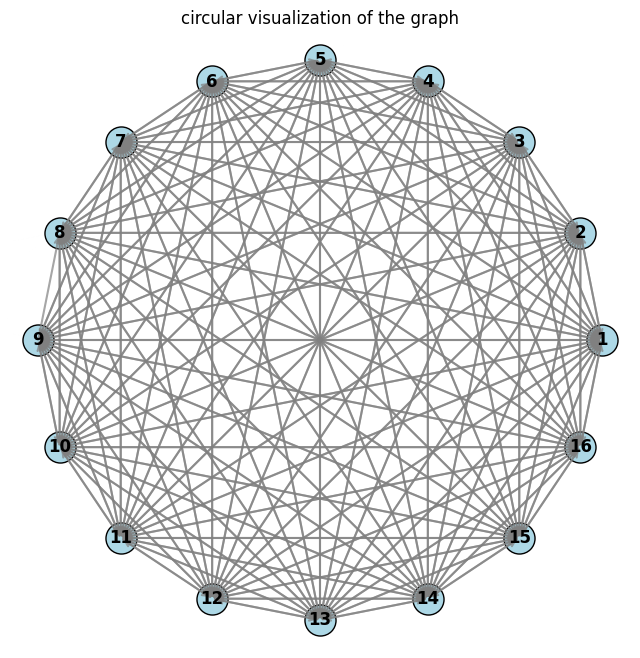

In [4]:
#directed
dot_file = data_name_7 
nodes, edges = parse_dot_file(dot_file)
circular_visualize_graph(nodes, edges)

Graph is undirected

Number of edges before conversion: 254

Number of edges after conversion: 508


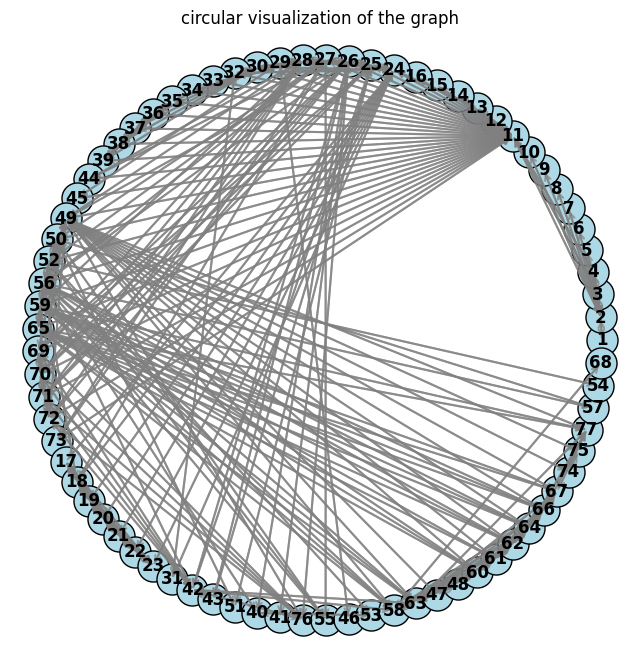

In [ ]:
#undirected
dot_file = data_name_2 
nodes, edges = parse_dot_file(dot_file)
circular_visualize_graph(nodes, edges)

### Resolve cycles with trivial heuristic

Graph is directed

Number of edges that have been reversed: 11

List of reversed edges: [('9', '4'), ('3', '18'), ('16', '17'), ('3', '17'), ('6', '20'), ('8', '12'), ('19', '21'), ('11', '21'), ('3', '22'), ('12', '23'), ('16', '24')]


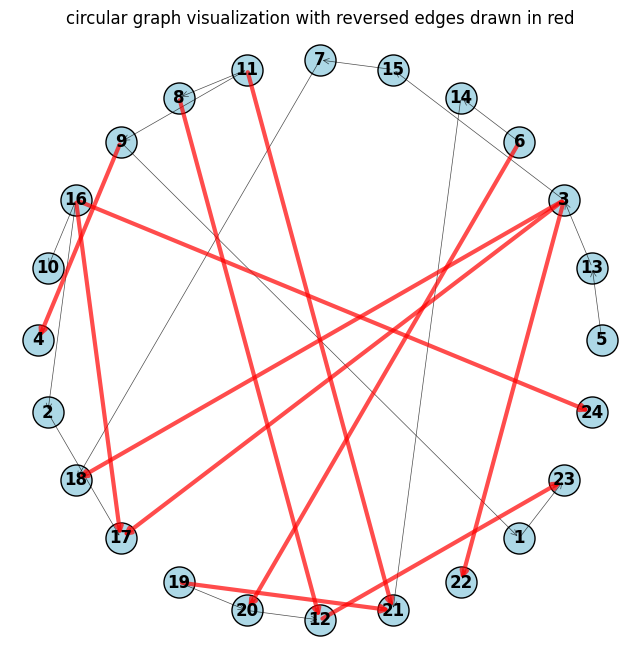

In [6]:
# small directed network
dot_file = data_name_9
nodes, edges = parse_dot_file(dot_file)
A, A_reverse = trivial_heuristic(nodes, edges)
final_edges, A_reversed = reversed_edges(A, A_reverse)
circular_reverse_graph(nodes, final_edges, A_reversed, A)

Graph is directed

Number of edges that have been reversed: 120

List of reversed edges: [('1', '2'), ('1', '3'), ('2', '3'), ('1', '4'), ('2', '4'), ('3', '4'), ('1', '5'), ('2', '5'), ('3', '5'), ('4', '5'), ('1', '6'), ('2', '6'), ('3', '6'), ('4', '6'), ('5', '6'), ('1', '7'), ('2', '7'), ('3', '7'), ('4', '7'), ('5', '7'), ('6', '7'), ('1', '8'), ('2', '8'), ('3', '8'), ('4', '8'), ('5', '8'), ('6', '8'), ('7', '8'), ('1', '9'), ('2', '9'), ('3', '9'), ('4', '9'), ('5', '9'), ('6', '9'), ('7', '9'), ('8', '9'), ('1', '10'), ('2', '10'), ('3', '10'), ('4', '10'), ('5', '10'), ('6', '10'), ('7', '10'), ('8', '10'), ('9', '10'), ('1', '11'), ('2', '11'), ('3', '11'), ('4', '11'), ('5', '11'), ('6', '11'), ('7', '11'), ('8', '11'), ('9', '11'), ('10', '11'), ('1', '12'), ('2', '12'), ('3', '12'), ('4', '12'), ('5', '12'), ('6', '12'), ('7', '12'), ('8', '12'), ('9', '12'), ('10', '12'), ('11', '12'), ('1', '13'), ('2', '13'), ('3', '13'), ('4', '13'), ('5', '13'), ('6', '13'), ('7', '

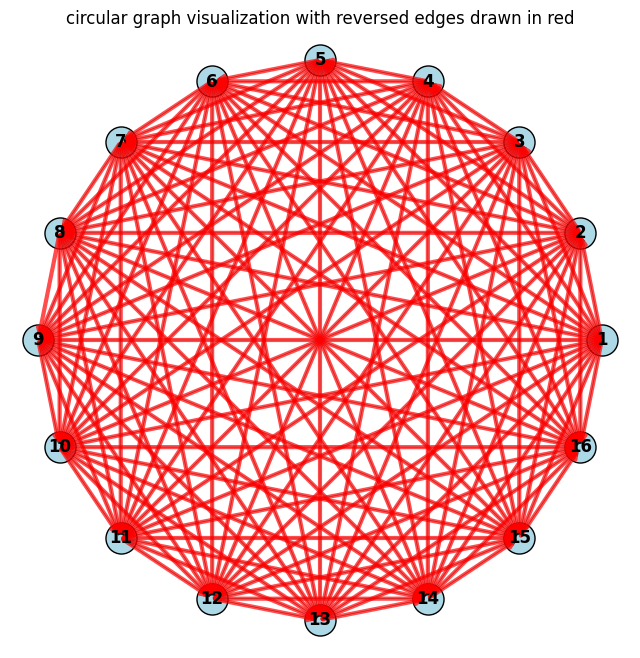

In [7]:
#league network
dot_file = data_name_7
nodes, edges = parse_dot_file(dot_file)
A, A_reverse = trivial_heuristic(nodes, edges)
final_edges, A_reversed = reversed_edges(A, A_reverse)
circular_reverse_graph(nodes, final_edges, A_reversed, A)

### Layer Assignment & number of crossings

Graph is directed

Number of edges that have been reversed: 11

List of reversed edges: [('9', '4'), ('3', '18'), ('16', '17'), ('3', '17'), ('6', '20'), ('8', '12'), ('19', '21'), ('11', '21'), ('3', '22'), ('12', '23'), ('16', '24')]


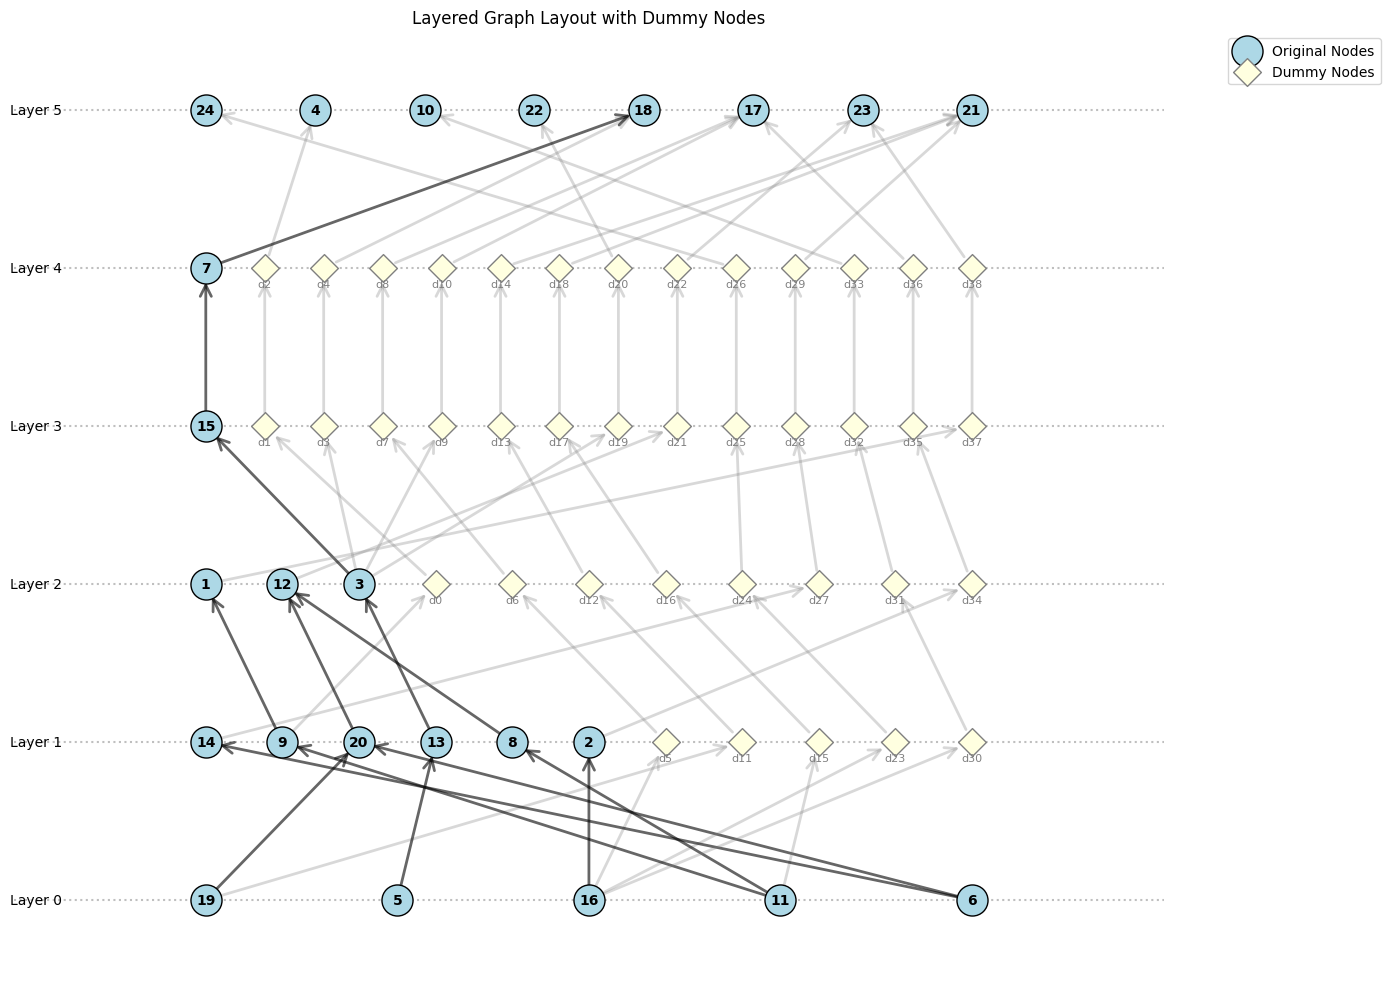

In [8]:
dot_file = data_name_9
nodes, edges = parse_dot_file(dot_file)

A, A_reverse = trivial_heuristic(nodes, edges)
final_edges, A_reversed = reversed_edges(A, A_reverse)

layers, modified_edges, dummy_mapping  = sugiyama_layer_assignment(nodes, final_edges)
positions = draw_layered_graph(layers, modified_edges, dummy_mapping)

In [9]:
num_crossings, crossing_pairs = count_edge_crossings(positions, modified_edges)
print(f"Number of edge crossings: {num_crossings}")
print("Crossing edge pairs:")
for edge_pair in crossing_pairs:
    print(f"  {edge_pair[0]} crosses {edge_pair[1]}")

Number of edge crossings: 115
Crossing edge pairs:
  ('9', 'dummy_0') crosses ('8', '12')
  ('9', 'dummy_0') crosses ('13', '3')
  ('9', 'dummy_0') crosses ('14', 'dummy_27')
  ('9', 'dummy_0') crosses ('20', '12')
  ('dummy_0', 'dummy_1') crosses ('3', 'dummy_3')
  ('dummy_0', 'dummy_1') crosses ('3', 'dummy_9')
  ('dummy_0', 'dummy_1') crosses ('3', 'dummy_19')
  ('dummy_0', 'dummy_1') crosses ('12', 'dummy_21')
  ('dummy_0', 'dummy_1') crosses ('1', 'dummy_37')
  ('dummy_2', '4') crosses ('dummy_26', '24')
  ('dummy_2', '4') crosses ('7', '18')
  ('3', 'dummy_3') crosses ('12', 'dummy_21')
  ('3', 'dummy_3') crosses ('1', 'dummy_37')
  ('dummy_4', '18') crosses ('dummy_20', '22')
  ('dummy_4', '18') crosses ('dummy_26', '24')
  ('dummy_4', '18') crosses ('dummy_33', '10')
  ('16', 'dummy_5') crosses ('6', '20')
  ('16', 'dummy_5') crosses ('19', 'dummy_11')
  ('16', 'dummy_5') crosses ('6', '14')
  ('16', 'dummy_5') crosses ('11', '8')
  ('16', 'dummy_5') crosses ('11', '9')
  ('dum

### Cross Minimizing


Initial crossing count: 115
----------------------------------------

Iteration 1
After downward sweep: 30 crossings
After upward sweep: 4 crossings

Iteration 2
After downward sweep: 8 crossings
After upward sweep: 8 crossings

Iteration 3
After downward sweep: 8 crossings
After upward sweep: 8 crossings

Pattern repeats (same crossing counts as previous iteration), stopping...

Final crossing count: 8
Total reduction: 107 crossings


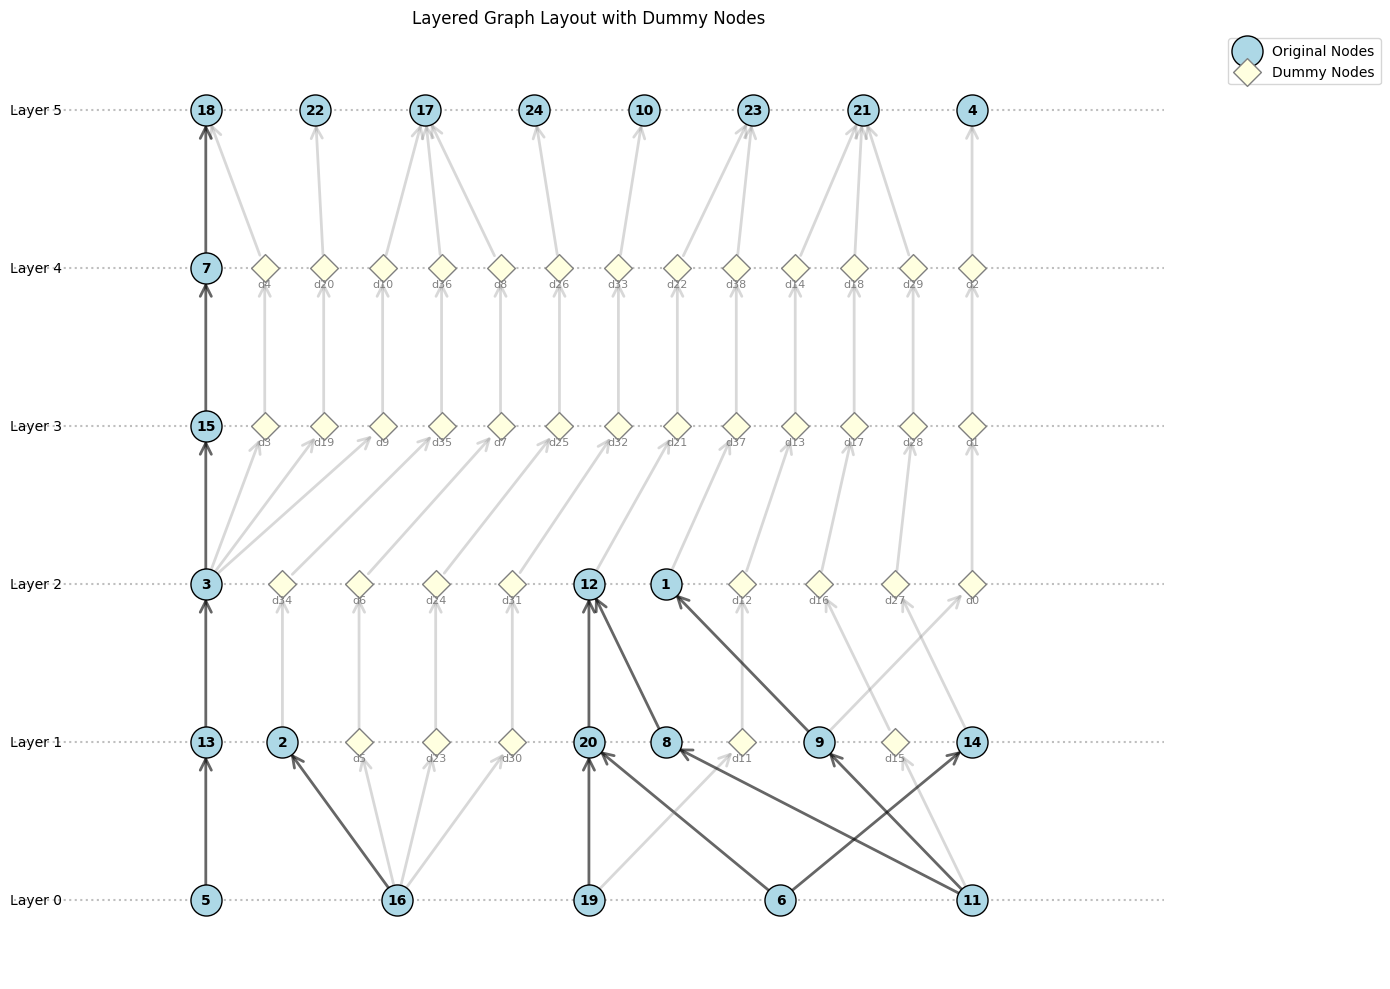

In [10]:
#apply the crossing minimization to the LeagueNetwork or noname network

layers, modified_edges, dummy_mapping = sugiyama_layer_assignment(nodes, final_edges)

# Apply crossing minimization
optimized_layers = minimize_crossings(
    layers=layers.copy(),  # Create a copy to preserve original
    edges=modified_edges,
    max_iterations=10,
    method='barycenter'  # or 'median'
)

# Visualize the result
positions = draw_layered_graph(optimized_layers, modified_edges, dummy_mapping)
plt.show()


Initial crossing count: 115
----------------------------------------

Iteration 1
After downward sweep: 30 crossings
After upward sweep: 4 crossings

Iteration 2
After downward sweep: 8 crossings
After upward sweep: 8 crossings

Iteration 3
After downward sweep: 8 crossings
After upward sweep: 8 crossings

Pattern repeats (same crossing counts as previous iteration), stopping...

Final crossing count: 8
Total reduction: 107 crossings


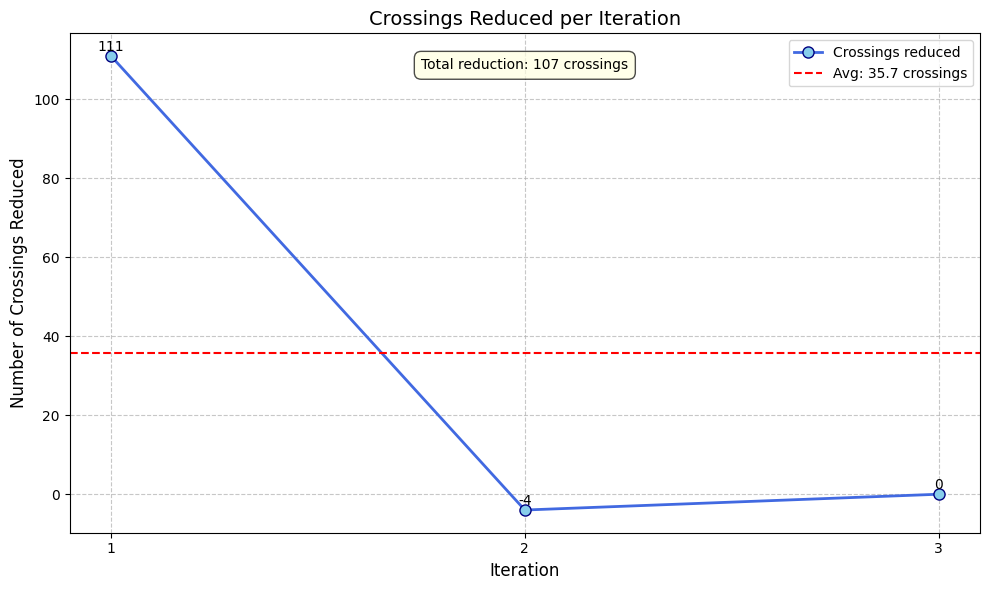

In [11]:
# Apply crossing minimization with detailed output
crossing_stats = minimize_crossings(
    layers=layers.copy(),
    edges=modified_edges,
    max_iterations=10,
    method='barycenter',  # or 'median'
    collect_stats =True  
)

# Extract data from crossing_stats (excluding the summary at the end)
iterations = [stat['iteration'] for stat in crossing_stats[:-1]]
crossings_reduced = [stat['crossings_reduced'] for stat in crossing_stats[:-1]]

# Create the line plot
plt.figure(figsize=(10, 6))
plt.plot(iterations, crossings_reduced, 'o-', color='royalblue', linewidth=2, 
         markersize=8, markerfacecolor='skyblue', markeredgecolor='navy', 
         label='Crossings reduced')

# Add a horizontal line showing the average reduction
avg_reduction = np.mean(crossings_reduced)
plt.axhline(y=avg_reduction, color='red', linestyle='--', 
            label=f'Avg: {avg_reduction:.1f} crossings')

# Add value labels above each point
for i, value in enumerate(crossings_reduced):
    plt.text(iterations[i], value + 0.5, f'{value:.0f}', 
             ha='center', va='bottom')

# Add title and labels
plt.title('Crossings Reduced per Iteration', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Number of Crossings Reduced', fontsize=12)
plt.xticks(iterations)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Add the total reduction as an annotation
total_reduction = crossing_stats[-1]['total_reduction']
plt.annotate(f'Total reduction: {total_reduction} crossings', 
             xy=(0.5, 0.95), xycoords='axes fraction',
             ha='center', va='top', 
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

### Node positioning


In [12]:
# First get all paths
paths = build_paths_from_layer_0(positions, modified_edges, dummy_mapping, max_depth=10)

# Optimize positions to straighten paths
optimized_positions = straighten_paths_quadratic_program(
    paths, 
    positions, 
    dummy_mapping, 
    min_distance=0.05,
    max_iterations=300
)

Found 5 nodes in layer 0
Finding paths from node 5 (1/5)
Finding paths from node 16 (2/5)
Finding paths from node 19 (3/5)
Finding paths from node 6 (4/5)
Finding paths from node 11 (5/5)
Found 16 total paths from layer 0 nodes
Optimizing node positions to straighten paths...
Preparing optimization for 63 nodes across 6 layers
Created 57 ordering constraints
Initial total deviation: 0.6103
Starting optimization...
Iteration 10: Deviation = 0.0708 (Improved by 88.39%)
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.08270925497816699
            Iterations: 19
            Function evaluations: 1230
            Gradient evaluations: 19
Optimization succeeded: Optimization terminated successfully

Final results:
Initial total deviation: 0.6103
Final total deviation: 0.0644
Improved by 89.45%
Moved 63 out of 63 nodes

Top 5 paths with greatest improvement:
1. Path 11 → 23: Improved by 0.2069 (96.2%)
2. Path 6 → 23: Improved by 0.0826 (93.1%)
3. Pa

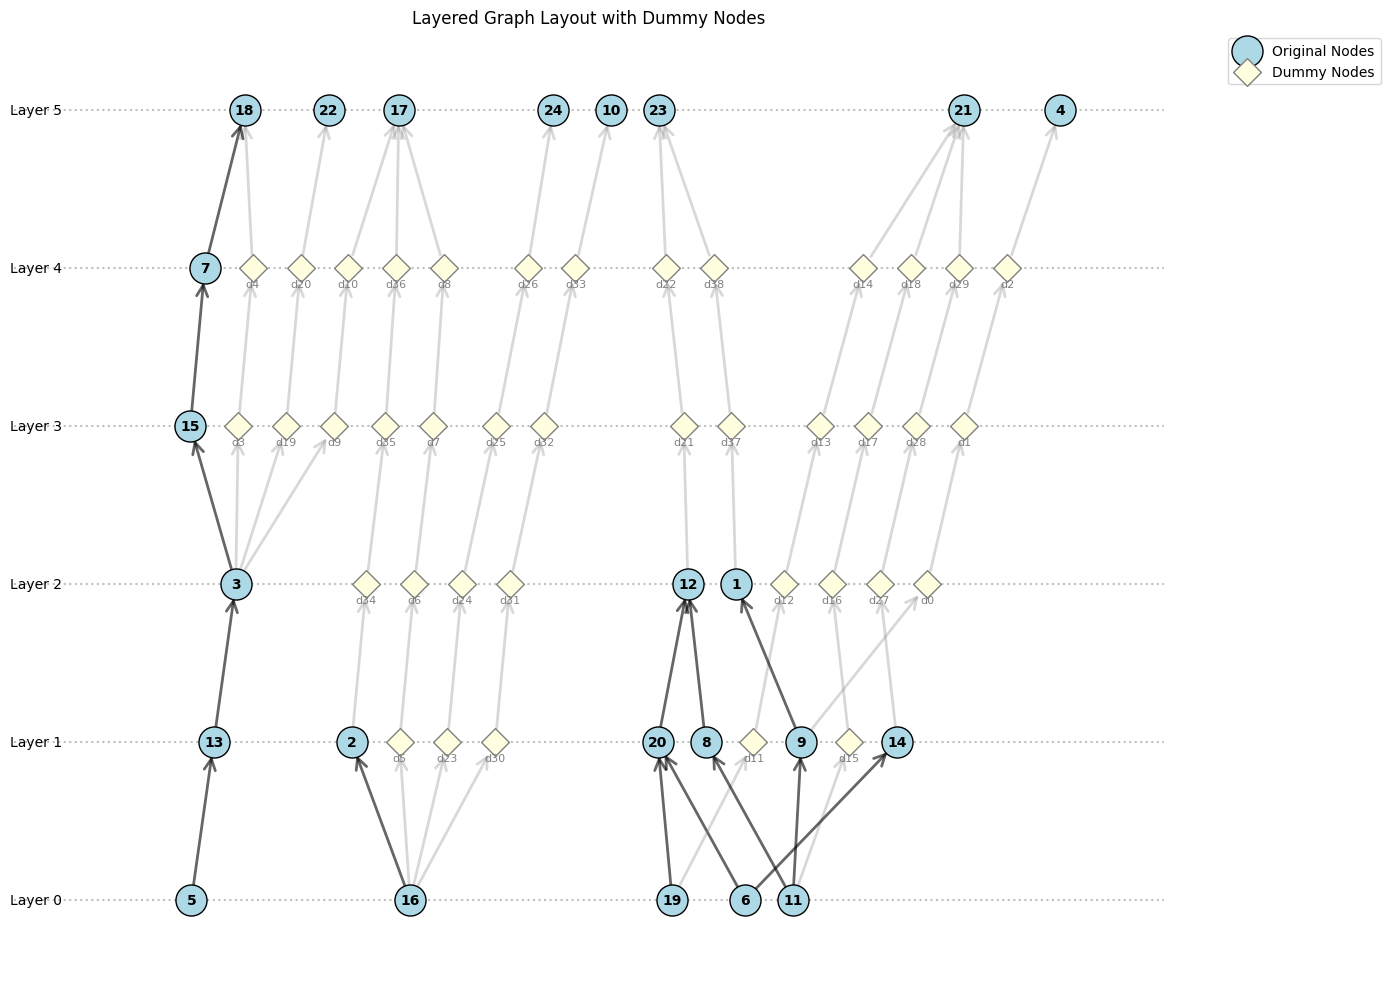

In [13]:
positions_draw_layered_graph(optimized_layers, modified_edges, dummy_mapping, optimized_positions)

### Quality Metrics

In [14]:
n_cross, cross = count_edge_crossings_final(optimized_positions,modified_edges)
print(f"\nNumber of edge crossings after optimization: {n_cross}")
print("\nCrossing edge pairs after optimization:")
for edge_pair in cross:
    print(f"  {edge_pair[0]} crosses {edge_pair[1]}")


Number of edge crossings after optimization: 8

Crossing edge pairs after optimization:
  ('9', 'dummy_0') crosses ('dummy_15', 'dummy_16')
  ('9', 'dummy_0') crosses ('14', 'dummy_27')
  ('6', '20') crosses ('19', 'dummy_11')
  ('19', 'dummy_11') crosses ('11', '8')
  ('dummy_11', 'dummy_12') crosses ('9', '1')
  ('11', 'dummy_15') crosses ('6', '14')
  ('6', '14') crosses ('11', '8')
  ('6', '14') crosses ('11', '9')


In [15]:
crossings, crossing_edge_pairs = count_edge_crossings_final(optimized_positions, modified_edges)


angle_results = calculate_crossing_angles(optimized_positions, crossing_edge_pairs)


crossings=0
for edge1, edge2, angle in angle_results:
    print(f"Edges {edge1} and {edge2} cross at an angle of {angle:.2f}°")
    crossings+=1
print(f"\nTotal number of crossings: {crossings}")

Edges ('9', 'dummy_0') and ('dummy_15', 'dummy_16') cross at an angle of 8.55°
Edges ('9', 'dummy_0') and ('14', 'dummy_27') cross at an angle of 8.55°
Edges ('6', '20') and ('19', 'dummy_11') cross at an angle of 10.06°
Edges ('19', 'dummy_11') and ('11', '8') cross at an angle of 10.06°
Edges ('dummy_11', 'dummy_12') and ('9', '1') cross at an angle of 5.72°
Edges ('11', 'dummy_15') and ('6', '14') cross at an angle of 5.66°
Edges ('6', '14') and ('11', '8') cross at an angle of 14.23°
Edges ('6', '14') and ('11', '9') cross at an angle of 8.52°

Total number of crossings: 8


In [16]:
stress_distribution = analyze_stress_distribution(optimized_positions, modified_edges)

Mean stress per pair: 1.8057
Median stress per pair: 2.0000
Max stress per pair: 5.0816
Standard deviation: 1.1906


### Edge reversing & drawing

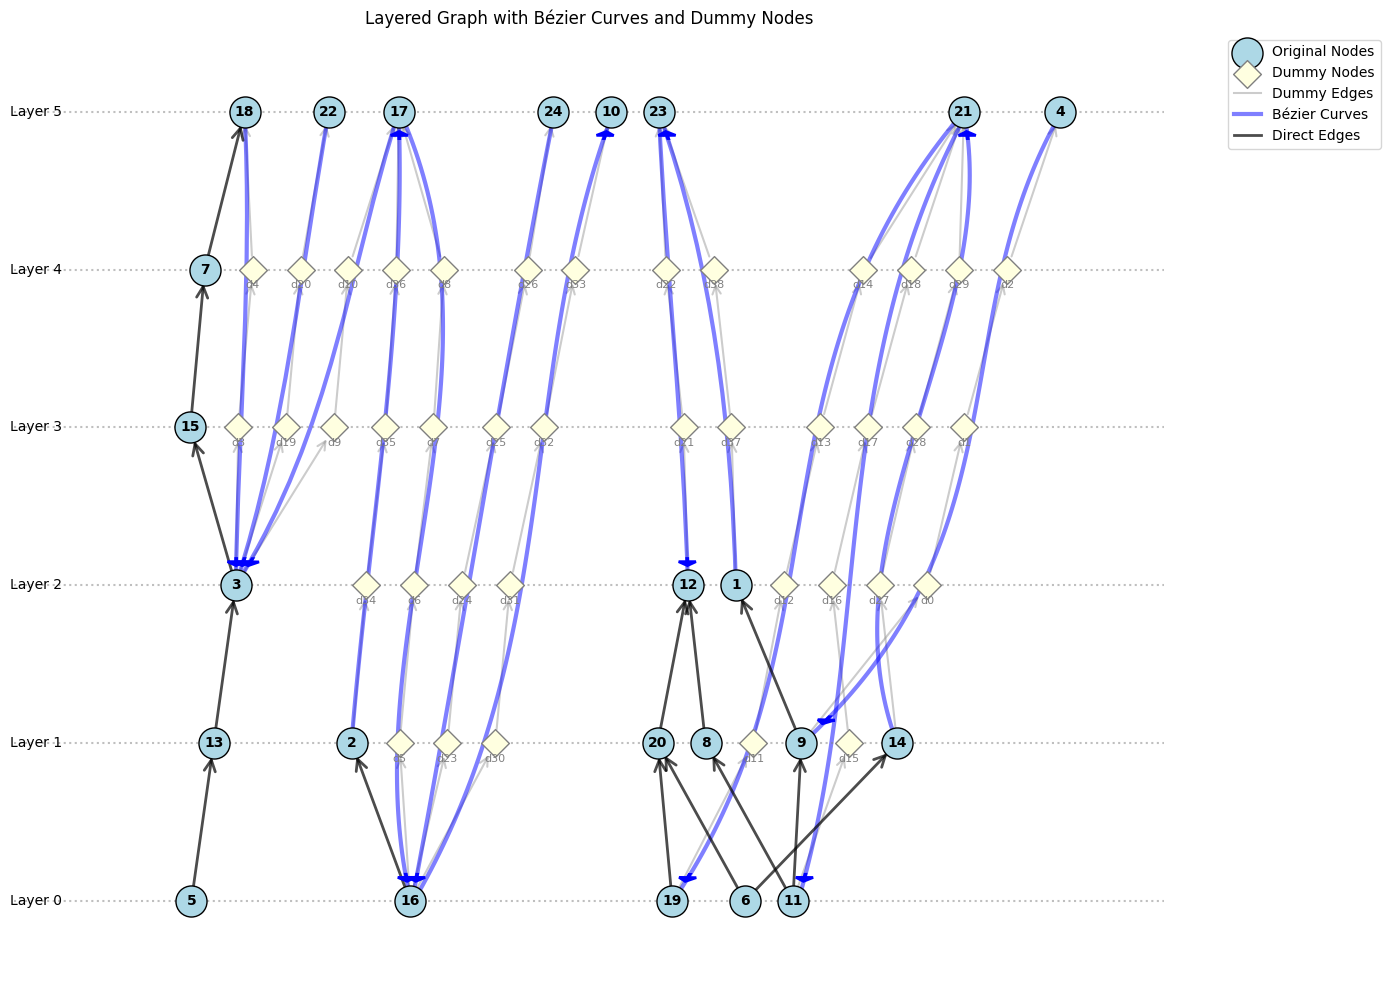

In [17]:
# with dummy nodes
positions = positions_draw_layered_graph_with_bezier(
    optimized_positions,
    optimized_layers, 
    modified_edges, 
    dummy_mapping,
    original_edges=edges,  # Pass original edges to determine direction
    show_dummies=True  # Set to True to show dummy nodes
)
plt.show()

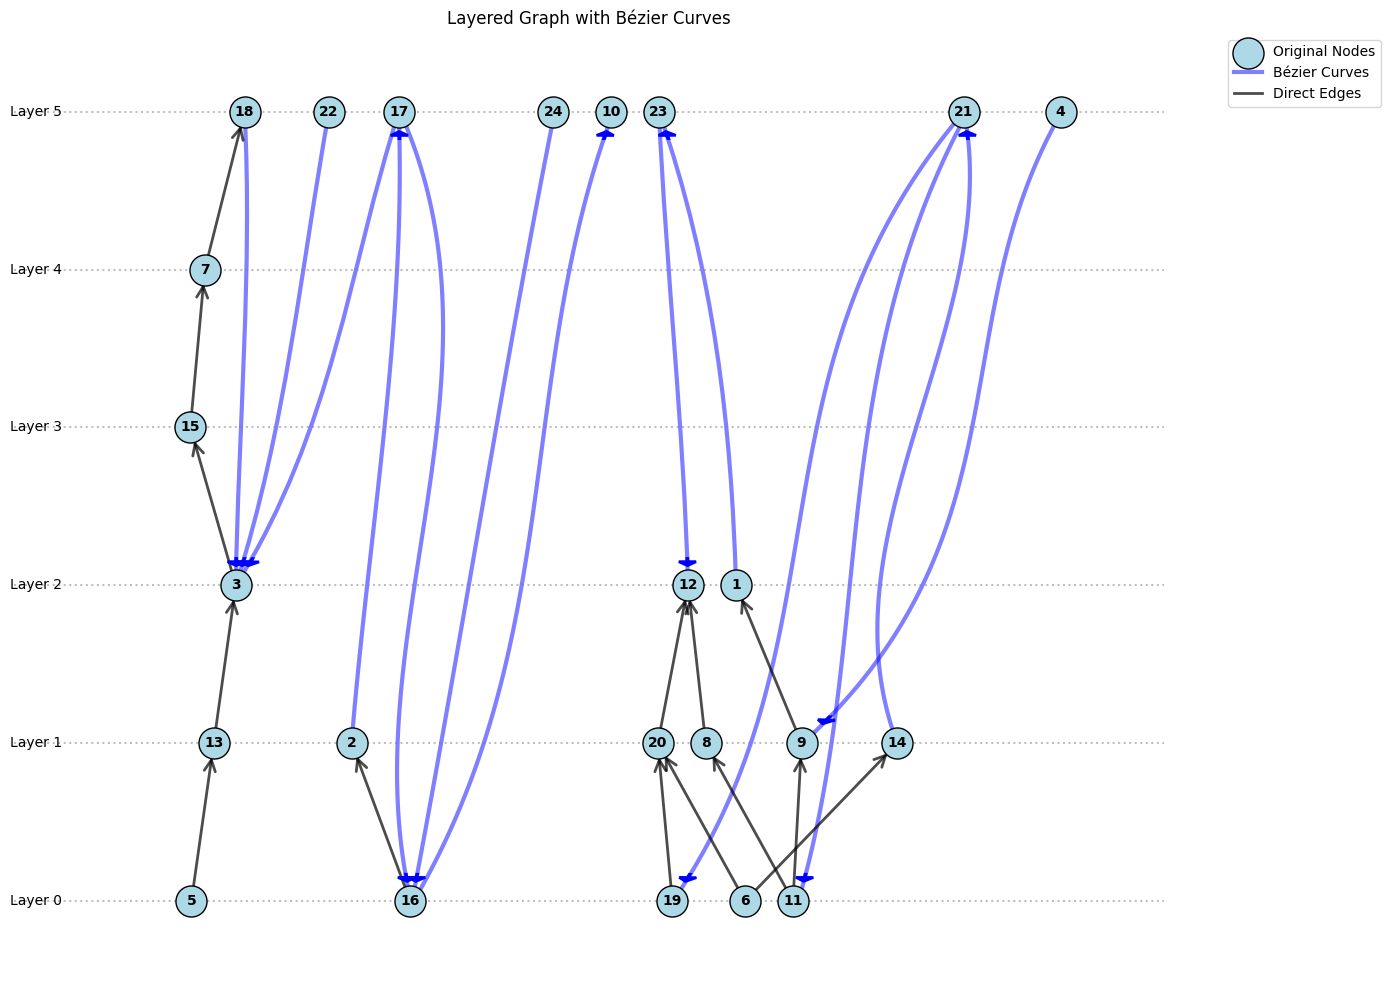

In [18]:
# without dummy nodes
positions = positions_draw_layered_graph_with_bezier(
    optimized_positions,
    optimized_layers, 
    modified_edges, 
    dummy_mapping,
    original_edges=edges,  # Pass original edges to determine direction
    show_dummies=False  # Set to True to show dummy nodes
)
plt.show()